# Model Monitoring and Feedback Loop

I move beyond model training and focus on how the credit-risk model would be monitored after deployment.

For me, this is an important part of building a production-style machine learning project because a model is not truly finished once it has been trained. In a real lending environment, I would need to monitor the data going into the model, the risk scores it produces, the decisions made from those scores, and the actual repayment outcomes that arrive later.

This step helps show how the model could be maintained, reviewed, and improved over time rather than treated as a one-off prediction exercise.


## 1. Environment Setup

Load libraries, connect to project files, and prepare output folders.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

project_root = Path.cwd().resolve().parents[0]
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from credit_risk_platform.data.german_credit import interim_german_credit_dir
from credit_risk_platform.utils.io import load_csv

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", context="talk")

tables_dir = project_root / "artifacts" / "tables"
profiles_dir = project_root / "artifacts" / "profiles"
figures_dir = project_root / "artifacts" / "figures"

tables_dir.mkdir(parents=True, exist_ok=True)
profiles_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

print("project_root:", project_root)

project_root: /Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform


## 2. Load Dataset and Champion Model

I used the saved Random Forest champion pipeline and the standardized dataset.

In [2]:
interim_dir = interim_german_credit_dir(project_root)
df = load_csv(interim_dir / "german_credit_standardized.csv")

champion_model_path = project_root / "models" / "random_forest_champion_pipeline.joblib"
champion_pipeline = joblib.load(champion_model_path)

print("Dataset shape:", df.shape)
print("Champion model loaded:", champion_model_path.exists())
df.head()

Dataset shape: (1000, 24)
Champion model loaded: True


,applicant_id,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_duration,installment_rate_pct_income,personal_status_sex,...,other_installment_plans,housing,existing_credits_count,job_type,liable_people_count,telephone,foreign_worker,risk_class,risk_label,TARGET
0,1,A11,6,A34,A43,1169,A65,A75,4,A93,...,A143,A152,2,A173,1,A192,A201,1,good,0
1,2,A12,48,A32,A43,5951,A61,A73,2,A92,...,A143,A152,1,A173,1,A191,A201,2,bad,1
2,3,A14,12,A34,A46,2096,A61,A74,2,A93,...,A143,A152,1,A172,2,A191,A201,1,good,0
3,4,A11,42,A32,A42,7882,A61,A74,2,A93,...,A143,A153,1,A173,2,A191,A201,1,good,0
4,5,A11,24,A33,A40,4870,A61,A73,3,A93,...,A143,A153,2,A173,2,A191,A201,2,bad,1


## 3. Reference and New Monitoring Samples

Also used the test set as a simulated future batch to demonstrate monitoring logic.

In [3]:
target_col = "TARGET"
identifier_cols = ["applicant_id"]
target_label_cols = ["risk_class", "risk_label"]
exclude_from_features = identifier_cols + target_label_cols + [target_col]

feature_cols = [col for col in df.columns if col not in exclude_from_features]
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_reference, X_new, y_reference, y_new = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Reference rows:", len(X_reference))
print("New batch rows:", len(X_new))

Reference rows: 150
New batch rows: 150


## 4. Score Reference and New Batches

I predicted high-risk probabilities and decision bands for both populations.

In [4]:
approve_threshold = 0.40
reject_threshold = 0.65

def assign_credit_decision(probability: float) -> str:
    if probability < approve_threshold:
        return "approve"
    if probability < reject_threshold:
        return "manual_review"
    return "reject"

def score_batch(X_batch: pd.DataFrame, y_batch: pd.Series, batch_name: str) -> pd.DataFrame:
    scores = champion_pipeline.predict_proba(X_batch)[:, 1]
    return pd.DataFrame(
        {
            "batch": batch_name,
            "actual_high_risk": y_batch,
            "predicted_high_risk_probability": scores,
            "decision": [assign_credit_decision(score) for score in scores],
        },
        index=X_batch.index,
    )

reference_scores = score_batch(X_reference, y_reference, "reference")
new_scores = score_batch(X_new, y_new, "new_batch")
monitoring_scores = pd.concat([reference_scores, new_scores])

monitoring_scores.head()

,batch,actual_high_risk,predicted_high_risk_probability,decision
309,reference,0,0.456577,manual_review
404,reference,0,0.290973,approve
940,reference,0,0.198351,approve
832,reference,1,0.720902,reject
575,reference,0,0.389639,approve


## 5. Monitor Score Drift

Compare predicted high-risk score distributions between the reference sample and the new batch.

In [5]:
score_drift_summary = (
    monitoring_scores.groupby("batch")["predicted_high_risk_probability"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(4)
    .reset_index()
)

score_drift_summary

,batch,count,mean,median,std,min,max
0,new_batch,150,0.3936,0.3872,0.1846,0.0575,0.7976
1,reference,150,0.4231,0.4251,0.1776,0.1016,0.7914


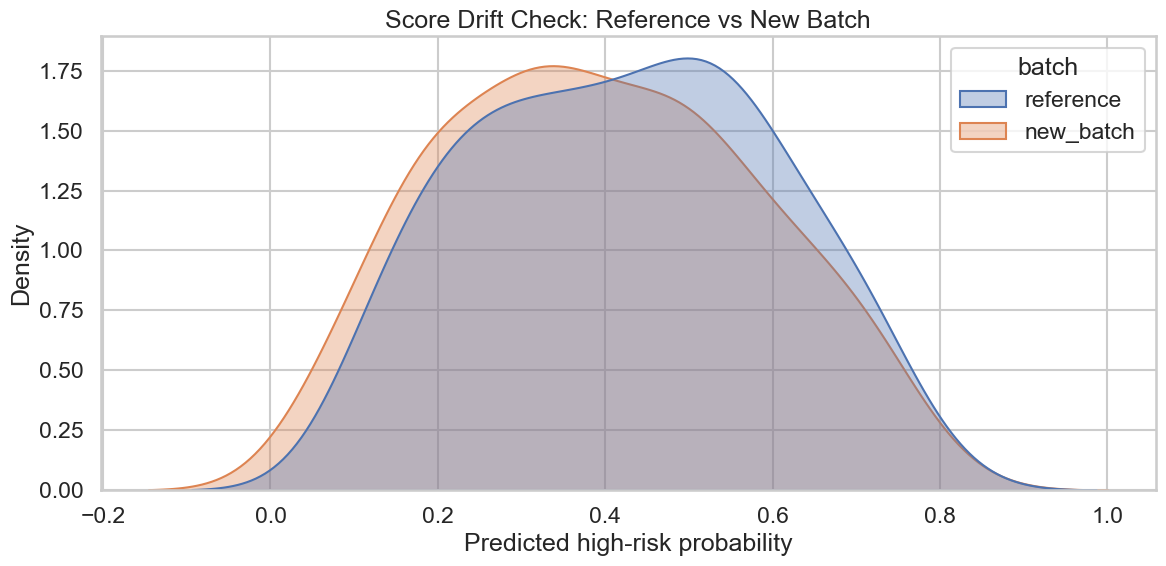

In [6]:
plt.figure(figsize=(12, 6))
sns.kdeplot(
    data=monitoring_scores,
    x="predicted_high_risk_probability",
    hue="batch",
    fill=True,
    common_norm=False,
    alpha=0.35,
)
plt.title("Score Drift Check: Reference vs New Batch")
plt.xlabel("Predicted high-risk probability")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(figures_dir / "score_drift_reference_vs_new_batch.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Monitor Decision-Mix Drift

I checked to ensure whether the share of approve, manual review, and reject decisions changes in the new batch.

In [7]:
decision_mix = (
    monitoring_scores.groupby(["batch", "decision"])
    .size()
    .reset_index(name="applicants")
)

decision_mix["share"] = decision_mix.groupby("batch")["applicants"].transform(lambda x: (x / x.sum()).round(4))
decision_mix

,batch,decision,applicants,share
0,new_batch,approve,78,0.5200
1,new_batch,manual_review,58,0.3867
2,new_batch,reject,14,0.0933
3,reference,approve,70,0.4667
4,reference,manual_review,62,0.4133
5,reference,reject,18,0.1200


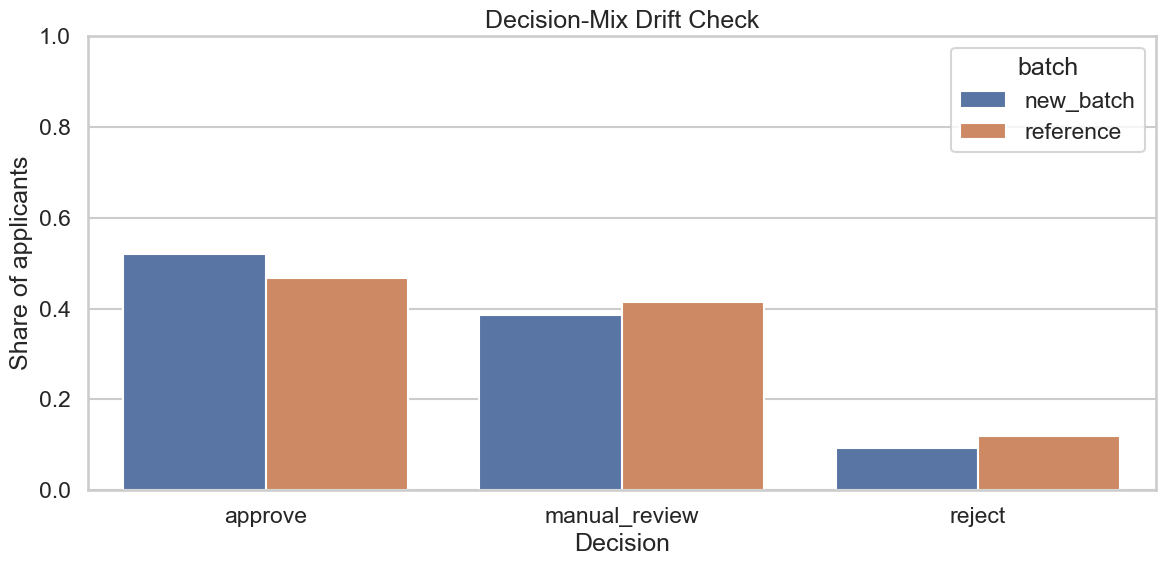

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(data=decision_mix, x="decision", y="share", hue="batch")
plt.title("Decision-Mix Drift Check")
plt.xlabel("Decision")
plt.ylabel("Share of applicants")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(figures_dir / "decision_mix_drift.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Monitor Key Feature Drift

I reviewed whether important numeric features changed between the reference sample and the new batch.

In [9]:
feature_monitor_cols = ["duration_months", "credit_amount", "age_years"]

reference_features = X_reference[feature_monitor_cols].assign(batch="reference")
new_features = X_new[feature_monitor_cols].assign(batch="new_batch")
feature_monitoring_df = pd.concat([reference_features, new_features])

feature_drift_summary = (
    feature_monitoring_df.groupby("batch")[feature_monitor_cols]
    .agg(["mean", "median", "std"])
    .round(2)
)

feature_drift_summary

duration_months               credit_amount                   \
                     mean median    std          mean  median      std   
batch                                                                    
new_batch           20.65   18.0  12.45       3183.07  2022.0  3081.77   
reference           21.78   18.0  12.16       3687.91  2669.5  3186.10   

          age_years                
               mean median    std  
batch                              
new_batch     35.81   32.0  12.61  
reference     35.65   32.5  12.07

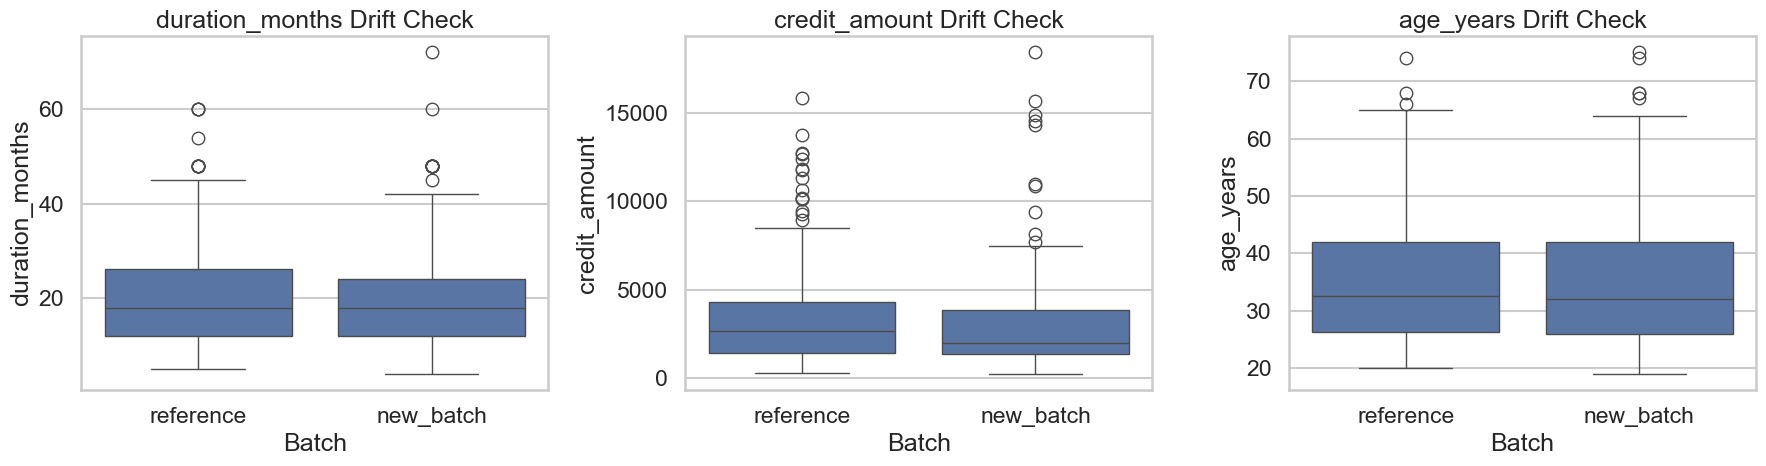

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, feature_monitor_cols):
    sns.boxplot(data=feature_monitoring_df, x="batch", y=col, ax=ax)
    ax.set_title(f"{col} Drift Check")
    ax.set_xlabel("Batch")

plt.tight_layout()
plt.savefig(figures_dir / "key_feature_drift_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Delayed Outcome Monitoring

In credit risk, true default or repayment outcomes arrive later. This means production monitoring must separate immediate monitoring from delayed performance monitoring.

In [12]:
delayed_outcome_plan = pd.DataFrame(
    [
        {
            "monitoring_layer": "Immediate monitoring",
            "what_to_track": "Input data, predicted risk scores, decision mix, API health",
            "why_it_matters": "Detects distribution shifts before repayment outcomes are available",
        },
        {
            "monitoring_layer": "Delayed outcome monitoring",
            "what_to_track": "Actual repayment/default outcomes joined back to original predictions",
            "why_it_matters": "Shows whether the model remains accurate after real outcomes mature",
        },
        {
            "monitoring_layer": "Retraining trigger",
            "what_to_track": "Performance decay, score drift, feature drift, policy changes",
            "why_it_matters": "Prevents unnecessary retraining while still responding to meaningful model degradation",
        },
    ]
)

delayed_outcome_plan

,monitoring_layer,what_to_track,why_it_matters
0,Immediate monitoring,"Input data, predicted risk scores, decision mi...",Detects distribution shifts before repayment o...
1,Delayed outcome monitoring,Actual repayment/default outcomes joined back ...,Shows whether the model remains accurate after...
2,Retraining trigger,"Performance decay, score drift, feature drift,...",Prevents unnecessary retraining while still re...


## 9. Save Monitoring Artifacts

Save score drift, decision drift, feature drift, and feedback-loop documentation outputs.

In [13]:
score_drift_path = tables_dir / "monitoring_score_drift_summary.csv"
decision_mix_path = tables_dir / "monitoring_decision_mix.csv"
feature_drift_path = tables_dir / "monitoring_feature_drift_summary.csv"
feedback_loop_path = tables_dir / "monitoring_feedback_loop_plan.csv"
monitoring_summary_path = profiles_dir / "model_monitoring_summary.json"

score_drift_summary.to_csv(score_drift_path, index=False)
decision_mix.to_csv(decision_mix_path, index=False)
feature_drift_summary.to_csv(feature_drift_path)
delayed_outcome_plan.to_csv(feedback_loop_path, index=False)

monitoring_summary = {
    "champion_model": "random_forest",
    "reference_batch": "validation sample",
    "new_batch": "simulated future batch using test sample",
    "monitored_outputs": [
        "score drift",
        "decision mix drift",
        "key feature drift",
        "delayed outcome feedback loop",
    ],
    "score_drift_path": str(score_drift_path.relative_to(project_root)),
    "decision_mix_path": str(decision_mix_path.relative_to(project_root)),
    "feature_drift_path": str(feature_drift_path.relative_to(project_root)),
    "feedback_loop_path": str(feedback_loop_path.relative_to(project_root)),
}

with monitoring_summary_path.open("w") as f:
    json.dump(monitoring_summary, f, indent=2)

score_drift_path, decision_mix_path, feature_drift_path, feedback_loop_path, monitoring_summary_path

(PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/monitoring_score_drift_summary.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/monitoring_decision_mix.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/monitoring_feature_drift_summary.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/tables/monitoring_feedback_loop_plan.csv'),
 PosixPath('/Users/ememakpan/Documents/New project/applied_ai_economics_portfolio/project_01_ai_credit_risk_platform/artifacts/profiles/model_monitoring_summary.json'))

## 10. Monitoring Summary

This monitoring step shows how the credit-risk model would be supervised after deployment. The main checks are score drift, decision-mix drift, and key feature drift.

Because credit outcomes are delayed, immediate monitoring cannot fully prove whether the model is still accurate. The feedback loop must connect future repayment/default outcomes back to the original predictions so the model can be reviewed, recalibrated, or retrained when needed.

This completes the production-style lifecycle from business problem to model training, explainability, decisioning, and monitoring.